# Operator-resolved Chern numbers and Berry density

`topology.chern(h,operator=...)` (equivalently `h.get_chern(operator=...)`) projects the Berry
curvature onto the expectation value of a chosen operator before integrating, giving e.g. a
spin-Chern or valley-Chern number instead of the total one. Below, a gapped (sublattice-imbalanced)
honeycomb lattice with zero *total* Chern number (time-reversal symmetric, no net Berry curvature)
still carries a non-zero **valley**-resolved Chern number: the two valleys contribute opposite,
non-cancelling Berry curvature once projected onto the valley operator.

Total Chern number  = 2.0055996682922695e-13
Valley Chern number = 1.0892120784394619


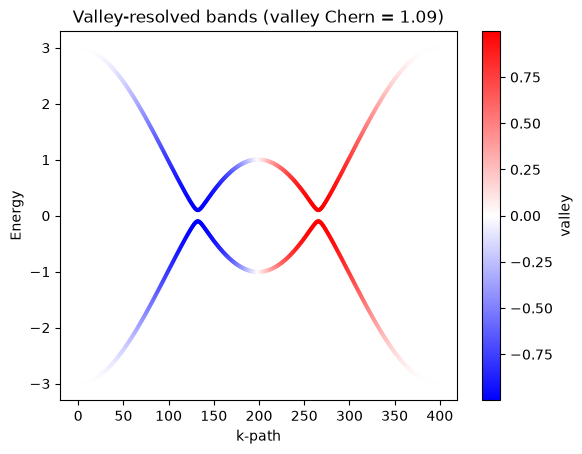

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import topology

g = geometry.honeycomb_lattice()
h = g.get_hamiltonian(has_spin=False)
h.add_sublattice_imbalance(0.1) # opens a trivial (non-topological) gap

C_total = topology.chern(h,mode="Green",delta=1e-4,nk=30)
op = h.get_operator("valley")
C_valley = topology.chern(h,mode="Green",delta=1e-4,nk=30,operator=op)

print("Total Chern number  =",C_total)
print("Valley Chern number =",C_valley)

(k,e,c) = h.get_bands(operator="valley",nk=400)
plt.scatter(k,e,c=c,cmap="bwr",s=4)
plt.colorbar(label="valley")
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title(f"Valley-resolved bands (valley Chern = {C_valley:.2f})")
plt.show()